In [100]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1 = nn.Linear(2, 16) # 2 inp and 16 out
        self.Layer2 = nn.Linear(16, 1) # 16 inp and 1 out
        self.activationFn = nn.ReLU()

    def forward(self, a):
        x = self.Layer1(a)
        x = self.activationFn(x)

        x = self.Layer2(x)

        return x

In [ ]:
N = 1_00_000

a = torch.rand(N) * 1000
b = torch.rand(N) * 1000

X = torch.stack([a, b], dim = 1)
y_real = torch.minimum(a, b).unsqueeze(1) # Unsqueeze makes it a 2D column (10_000, 1)

In [103]:
# Tensor DataSet : Think of it like a dataframe but of tensors
from torch.utils.data import TensorDataset

ds = TensorDataset(X, y_real)

# index 0 → (X[0], y[0])
# index 1 → (X[1], y[1])
# index 2 → (X[2], y[2])
# ...
# index 99999 → (X[99999], y[99999])
a, b = ds[0]
print(a)
print(b)

tensor([24.4489, 61.0618])
tensor([24.4489])


In [104]:
# Dataloader

from torch.utils.data import DataLoader
loader = DataLoader(
    ds,
    batch_size=128,
    shuffle = True
)

# Dataset size = 100,000
# Batch size   = 128
# Batches      = 782

print(len(loader))

782


In [105]:
model = MyModel()
loss_fn = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), 0.01)
loss = torch.tensor(float("inf"))
loss_history = []
traversal_history = []

In [ ]:
accuracy = 0.01
epoachs = 20
i = 0
j = 0
while loss.item() > accuracy:

    if i >= epoachs:
        break
    for X_sample, y_sample in loader:

        # Reset Gradients
        optimiser.zero_grad()

        # Forward Pass
        y_pred = model(X_sample)

        # loss
        loss = loss_fn(y_pred, y_sample)
        loss_history.append(loss.item())

        # Backward
        loss.backward()

        # Change Weights and biases
        optimiser.step()

        # For Seaborn
        j += 1

    i += 1
    traversal_history.append(j)
    print(f"Traversal {i} : loss = {loss.item()}")



Traversal 1 : loss = 0.00923627894371748


In [ ]:
def smallest(a):
    if isinstance(a, torch.Tensor):
        x = a
    else:
        x = torch.tensor([a], dtype = torch.float32)

    with torch.no_grad():
        return round(model(x).item())

print(smallest([[2, 9]]))
print(smallest([[8, 3]]))
print(smallest([[10, 10]]))
print(smallest([[17, 4]]))
print(smallest([[1, 19]]))


-356
0
99
0
-553101440
9912164352
-2
0


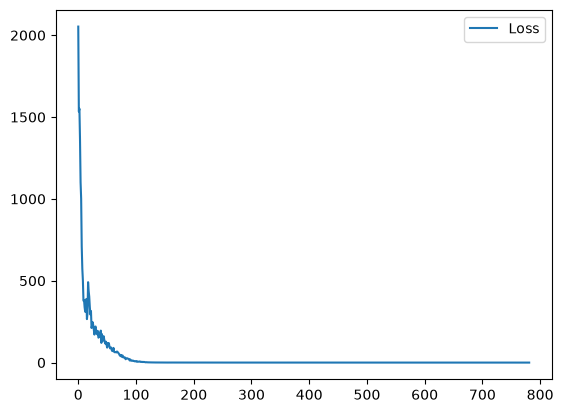

In [110]:
# Visualising Loss overtime
sns.lineplot(
    x = list(range(j)),
    y = loss_history,
    label = "Loss"
)

plt.show()